# Week 5: Reshaping Data & Python Files

This notebook has **two parts**:

1. **Part 1 – Reshaping in a notebook**: Learn why data comes in different shapes and how to use `pivot()` to change it.
2. **Part 2 – Python files**: See how we can put that exact same logic into `.py` files and call it from the notebook.

---

## Why does data shape matter?

Data can be stored in two common shapes:

| Shape | What it looks like | Example |
|-------|--------------------|---------|
| **Long** | One row per observation (country + year + variable) | Each row is one economic indicator for one country in one year |
| **Wide** | One row per entity, each variable gets its own column | Each row is one country-year, with GDP, inflation, unemployment as separate columns |

Both shapes are useful. Long is great for storing and filtering; wide is great for analysis and visualization.

`pivot()` converts **long → wide**.

---
# Part 1: Reshaping Data in the Notebook

## 1.1 Load the data

We will use the **IMF World Economic Outlook** dataset.
It is stored in **long format**: each row is one country, one year, and one economic variable.

In [22]:
import pandas as pd

In [24]:
data_path = "../../data/examples/week_5/imf_weo_countries.parquet"
df_raw = pd.read_parquet(data_path)
df_raw.head(2)

,weo_country_code,iso,weo_subject_code,country,subject_descriptor,subject_notes,units,scale,country_series-specific_notes,estimates_start_after,unnamed:_60,year,value
0,512,AFG,NGDP_R,Afghanistan,"Gross domestic product, constant prices",Expressed in billions of national currency uni...,National currency,Billions,Source: National Statistics Office Latest actu...,2024,NaN,1980,NaN
1,512,AFG,NGDP_RPCH,Afghanistan,"Gross domestic product, constant prices",Annual percentages of constant price GDP are y...,Percent change,Units,"See notes for: Gross domestic product, consta...",2024,NaN,1980,NaN


The raw dataset has many columns. Let's look at the unique **subject codes** — these are the different economic variables stored in each row.

In [25]:
df_raw['weo_subject_code'].unique()[:10]

<ArrowStringArray>
[    'NGDP_R',  'NGDP_RPCH',       'NGDP',      'NGDPD',     'PPPGDP',
     'NGDP_D',    'NGDPRPC', 'NGDPRPPPPC',     'NGDPPC',    'NGDPDPC']
Length: 10, dtype: str

## 1.2 Clean: keep only the columns and variables we need

We will focus on three variables:
- `NGDP_RPCH` — GDP growth rate (%)
- `LUR` — Unemployment rate (%)
- `PCPIPCH` — Inflation rate (%)

In [28]:
# Keep only the columns we need
cols = ["iso", "year", "weo_subject_code", "value"]
df = df_raw[cols]
df.head(2)
#df.weo_subject_code.unique()

,iso,year,weo_subject_code,value
0,AFG,1980,NGDP_R,NaN
1,AFG,1980,NGDP_RPCH,NaN


In [32]:

# Keep only the three subject codes
codes_to_keep = ["NGDP_RPCH", "LUR", "PCPIPCH"]
df = df.query("weo_subject_code in @codes_to_keep")
df.head(2)
#df.weo_subject_code.unique()

,iso,year,weo_subject_code,value
1,AFG,1980,NGDP_RPCH,NaN
17,AFG,1980,PCPIPCH,NaN


In [33]:
# Drop rows with missing values
df = df.dropna(subset=["value"])
df.head(2)
df.info()

<class 'pandas.DataFrame'>
Index: 22401 entries, 45 to 431222
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   iso               22401 non-null  str    
 1   year              22401 non-null  int64  
 2   weo_subject_code  22401 non-null  str    
 3   value             22401 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 1.1 MB


In [35]:
# Convert year to integer
df["year"] = df["year"].astype(int)

df.head(6)
df.info()

<class 'pandas.DataFrame'>
Index: 22401 entries, 45 to 431222
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   iso               22401 non-null  str    
 1   year              22401 non-null  int64  
 2   weo_subject_code  22401 non-null  str    
 3   value             22401 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 1.1 MB


**This is the long format.** Each row is a unique combination of `(country, year, variable)`. Notice that for the same country and year there are multiple rows — one for each economic variable.

In [36]:
# Example: Japan in 2020 -- three rows, one per variable
df.query("iso == 'JPN' and year == 2020")

,iso,year,weo_subject_code,value
348741,JPN,2020,NGDP_RPCH,-4.168
348757,JPN,2020,PCPIPCH,-0.027
348764,JPN,2020,LUR,2.800


## 1.3 Reshape: `pivot()` from long to wide

`pivot()` takes three arguments:

| Argument | Meaning |
|----------|---------|
| `index`  | The column(s) that identify each unique row in the output |
| `columns` | The column whose values become new column headers |
| `values` | The column whose values fill the new wide table |

We want:
- `index` = `["iso", "year"]` — one row per country-year
- `columns` = `"weo_subject_code"` — each code becomes a column
- `values` = `"value"` — the numbers fill the table

In [37]:
df_wide = df.pivot(index=["iso", "year"], columns="weo_subject_code", values="value")
df_wide.head(2)

weo_subject_code  LUR  NGDP_RPCH  PCPIPCH
iso year                                 
ABW 1987          NaN     16.079    3.639
    1988          NaN     18.640    3.121

In [38]:
df_wide = df_wide.reset_index()
df_wide.columns.name = None  # Remove the label 'weo_subject_code' from the column axis
df_wide.head(5)

,iso,year,LUR,NGDP_RPCH,PCPIPCH
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121
2,ABW,1989,NaN,12.095,3.989
3,ABW,1990,NaN,3.977,5.838
4,ABW,1991,6.078,7.975,5.553


**This is the wide format.** Each row is now one country-year, and each economic variable has its own column.

Let's verify: Japan in 2020 is now just ONE row.

In [39]:
df_wide.query("iso == 'JPN' and year == 2020")

,iso,year,LUR,NGDP_RPCH,PCPIPCH
4151,JPN,2020,2.8,-4.168,-0.027


In [40]:
df.query("iso == 'JPN' and year == 2020")

,iso,year,weo_subject_code,value
348741,JPN,2020,NGDP_RPCH,-4.168
348757,JPN,2020,PCPIPCH,-0.027
348764,JPN,2020,LUR,2.800


## 1.4 Rename columns to something readable

The column names are still the IMF codes. Let's rename them.

In [41]:
rename_map = {
    "NGDP_RPCH": "gdp_growth",
    "LUR": "unemployment",
    "PCPIPCH": "inflation",
}
df_wide = df_wide.rename(columns=rename_map)
df_wide.head(5)

,iso,year,unemployment,gdp_growth,inflation
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121
2,ABW,1989,NaN,12.095,3.989
3,ABW,1990,NaN,3.977,5.838
4,ABW,1991,6.078,7.975,5.553


## 1.5 Quick visualization to confirm the data makes sense

Now that the data is in wide format, it is easy to plot one variable against another — for example, GDP growth over time for Japan.

In [42]:
df_jpn = df_wide.query("iso == 'JPN'").set_index("year")
df_jpn.head(2)

,iso,unemployment,gdp_growth,inflation
year,,,,
1980,JPN,2.017,3.181,7.808
1981,JPN,2.208,4.261,4.936


<Axes: title={'center': 'Japan: Key Economic Indicators'}, xlabel='year'>

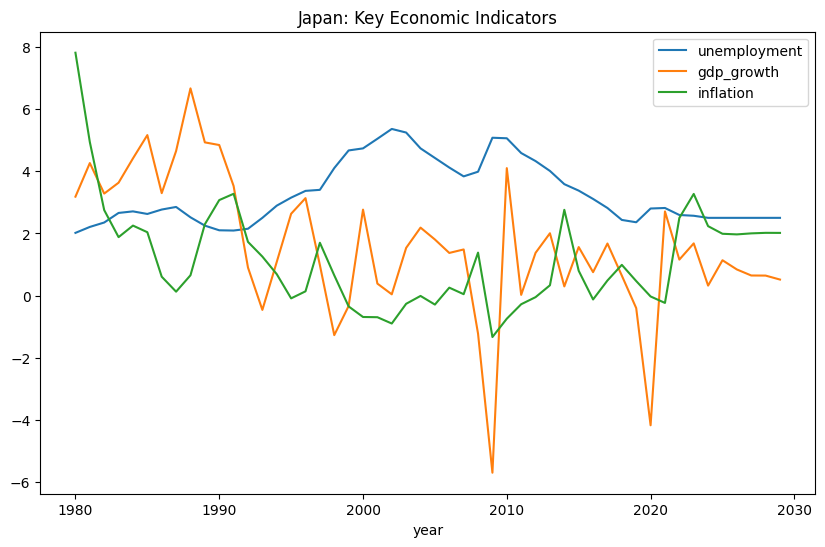

In [43]:
df_jpn.plot(figsize=(10, 6), title="Japan: Key Economic Indicators")

---
# Part 2: Moving Code into Python Files

Everything we just did in Part 1 is great — but notebooks have a problem: **the code only lives in the notebook**.

If another notebook, or a colleague, wants to do the same import + pivot, they have to copy-paste all that code. That leads to bugs, duplication, and maintenance headaches.

**The solution: put reusable logic in `.py` files.**

We have already created two files for you:

```
src/
└── data/
    ├── data_import.py     ← load_imf_data() function  (loads + cleans the long data)
    └── data_manipulate.py ← pivot_to_wide() function  (pivots long → wide)
```

Each file contains a **plain Python function**. Let's look at what they contain, then use them.

## 2.1 `load_imf_data` — loading and cleaning the raw data

This is **exactly** what we did manually in Part 1, now in a seperate file

## 2.2 `pivot_to_wide` — the pivot

Open `src/data/data_manipulate.py` and you will see:

```python
import pandas as pd

# Maps the raw IMF subject codes to human-readable column names
RENAME_MAP = {
    "NGDP_RPCH": "gdp_growth",
    "LUR": "unemployment",
    "PCPIPCH": "inflation",
}


def pivot_to_wide(df):
    # pivot() reshapes the data from long format to wide format:
    #   index   = the columns that identify each unique row in the output
    #   columns = the column whose values become new column headers
    #   values  = the column whose numbers fill the table
    df_wide = df.pivot(index=["iso", "year"], columns="weo_subject_code", values="value")
    # Move iso and year back from the index into regular columns
    df_wide = df_wide.reset_index()
    # Remove the axis label "weo_subject_code" that pivot() adds automatically
    df_wide.columns.name = None
    # Rename the IMF codes to plain English
    df_wide = df_wide.rename(columns=RENAME_MAP)
    return df_wide
```

Again — exactly the pivot steps from Part 1, now in a plain function.

## 2.3 Import the functions and run them

We need to tell Python where to find our `src` folder. We do this by adding the project root to the path.

In [45]:
import sys
sys.path.insert(0, "../..")

In [46]:
from src.data.data_import import load_imf_data
from src.data.data_manipulate import pivot_to_wide

### Step 1: Load and clean the data

In [47]:
df_long = load_imf_data()
df_long.head(2)

,iso,year,weo_subject_code,value
45,ALB,1980,NGDP_RPCH,2.684
68,ALB,1980,LUR,5.028


In [50]:
print("Shape (long):", df_long.shape) # This line prints the shape of the data

Shape (long): (22401, 4)


### Step 2: Pivot to wide format

In [51]:
from src.data.data_manipulate import pivot_to_wide
df_wide_from_fn = pivot_to_wide(df_long)
df_wide_from_fn.head(2)

,iso,year,unemployment,gdp_growth,inflation
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121


In [53]:
print("Shape (wide):", df_wide_from_fn.shape)
df_wide_from_fn.head(5)

Shape (wide): (8979, 5)


,iso,year,unemployment,gdp_growth,inflation
0,ABW,1987,NaN,16.079,3.639
1,ABW,1988,NaN,18.640,3.121
2,ABW,1989,NaN,12.095,3.989
3,ABW,1990,NaN,3.977,5.838
4,ABW,1991,6.078,7.975,5.553


**The result is identical to what we produced in Part 1** — but now the logic lives in reusable `.py` files.

Any other notebook (or script) in the project can do:

```python
from src.data.data_import import load_imf_data
from src.data.data_manipulate import pivot_to_wide

df_long = load_imf_data()
df_wide = pivot_to_wide(df_long)
```

No copy-pasting. No duplication.

## 2.4 Same visualization — same result

Let's reproduce the Japan chart from Part 1 using the function output to confirm everything matches.

array([<Axes: xlabel='year'>, <Axes: xlabel='year'>,
       <Axes: xlabel='year'>], dtype=object)

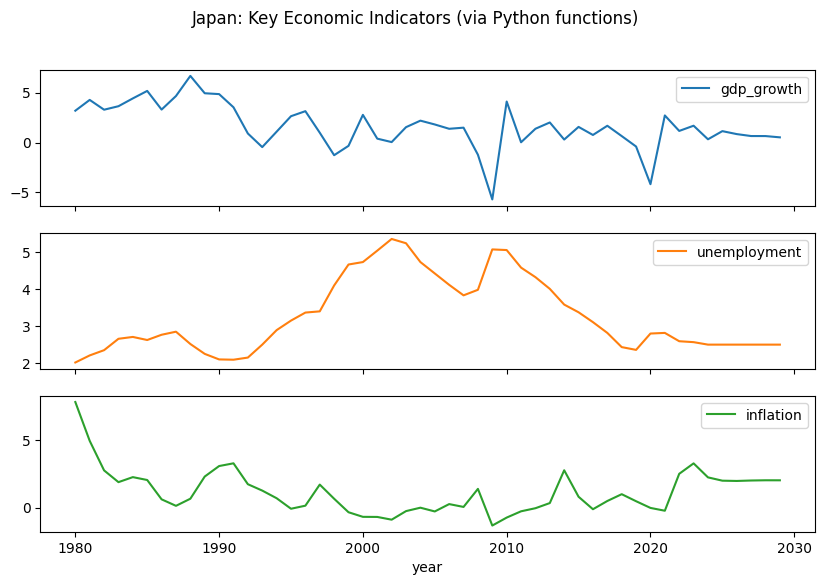

In [55]:
df_jpn2 = df_wide_from_fn.query("iso == 'JPN'").set_index("year")
df_jpn2[["gdp_growth", "unemployment", "inflation"]].dropna().plot(
    subplots=True, figsize=(10, 6), title="Japan: Key Economic Indicators (via Python functions)"
)

---
## Summary of Part 2

| | Part 1 (notebook) | Part 2 (Python files) |
|---|---|---|
| Where is the code? | Inside the notebook | In `src/data/*.py` |
| Can other notebooks reuse it? | No (copy-paste required) | **Yes** — just import |
| Easy to test? | Manual | Can write unit tests |
| Result | Same wide DataFrame | Same wide DataFrame |

**Key takeaway**: Notebooks are great for exploration. Python files are great for logic you want to reuse. In professional data science work, you do both — explore in notebooks, then move the logic to `.py` files.

## 3.3 Merging -- joining two datasets

So far we have only worked with **one** dataset at a time. In the real world, useful data often lives in **separate files** and must be combined.

We will join the **IMF economic data** with the **World Happiness Report** dataset.

### Why merge?

We want to answer: *Do wealthier countries tend to have happier populations?*

- The IMF data has **GDP per capita** for every country.
- The World Happiness Report has a **happiness score** ("ladder score") for every country.
- Neither file alone can answer the question -- we need **both**.

### How merging works

`pd.merge(left, right, on=key, how=join_type)` works like a database join:

| `how` | What rows appear in the result |
|-------|---------------------------------|
| `inner` | Only rows that appear in **both** tables |
| `left` | All rows from the **left** table; NaN if no match on the right |
| `right` | All rows from the **right** table; NaN if no match on the left |
| `outer` | All rows from **either** table; NaN where there is no match |

### Step 1 -- Load the World Happiness data

In [57]:
import pandas as pd
happiness_path = "../../data/examples/week_5/world_happiness.parquet"
df_happy = pd.read_parquet(happiness_path)
print("Shape:", df_happy.shape)
df_happy[["country_name", "ladder_score"]].head(5)

Shape: (143, 11)


,country_name,ladder_score
0,Finland,7.7407
1,Denmark,7.5827
2,Iceland,7.5251
3,Sweden,7.3441
4,Israel,7.3411


### Step 2 -- Prepare the GDP per capita column from the IMF data

The IMF code `NGDPDPC` is **GDP per capita in USD** (current prices).
We filter to the most recent year available (2023) and keep country name + value.

In [58]:
# Load raw IMF data again and clean column names
df_imf_raw = pd.read_parquet("../../data/examples/week_5/imf_weo_countries.parquet")
df_imf_raw.columns = df_imf_raw.columns.str.lower().str.replace(" ", "_")

# Filter to GDP per capita (NGDPDPC) in 2023
df_gdp_pc = df_imf_raw.query("weo_subject_code == 'NGDPDPC' and year == 2023")[["country", "value"]].dropna().rename(columns={"country": "country_name", "value": "gdp_per_capita"})

print("Shape:", df_gdp_pc.shape)
df_gdp_pc.head(5)

Shape: (193, 2)


,country_name,gdp_per_capita
370884,Afghanistan,410.933
370928,Albania,8299.278
370972,Algeria,5221.813
371016,Andorra,43809.726
371060,Angola,2967.384


### Step 3 -- Merge on `country_name`

Both DataFrames share a `country_name` column -- that is our **join key**.
We use `how='inner'` so we only keep countries that appear in **both** datasets.

In [60]:
df_merged = pd.merge(
    df_happy[["country_name", "ladder_score"]],
    df_gdp_pc,
    on="country_name",
    how="inner",
)

print("Merged shape:", df_merged.shape)
df_merged.head(5)

Merged shape: (129, 3)


,country_name,ladder_score,gdp_per_capita
0,Finland,7.7407,53130.693
1,Denmark,7.5827,68618.872
2,Iceland,7.5251,83485.110
3,Sweden,7.3441,55433.135
4,Israel,7.3411,52643.451


**129 countries** matched between the two datasets (out of 143 in the happiness report -- a few country names differ slightly between sources).

### Step 4 -- Scatter plot: GDP per capita vs Happiness

Now that both variables are in the same DataFrame, plotting is straightforward.

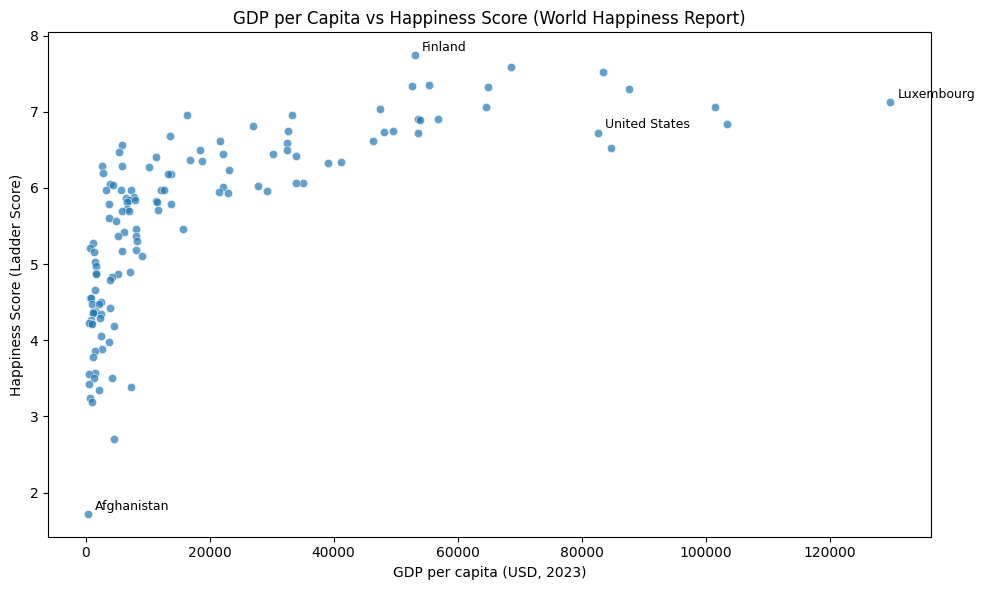

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_merged["gdp_per_capita"],
    df_merged["ladder_score"],
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
)

# Annotate a few interesting countries
for _, row in df_merged.iterrows():
    if row["country_name"] in ["Finland", "United States", "Luxembourg", "Afghanistan"]:
        ax.annotate(
            row["country_name"],
            xy=(row["gdp_per_capita"], row["ladder_score"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=9,
        )

ax.set_xlabel("GDP per capita (USD, 2023)")
ax.set_ylabel("Happiness Score (Ladder Score)")
ax.set_title("GDP per Capita vs Happiness Score (World Happiness Report)")
plt.tight_layout()
plt.show()

The scatter plot shows a clear **positive relationship**: countries with higher GDP per capita tend to have higher happiness scores. The relationship flattens at very high income levels (a pattern sometimes called the *Easterlin paradox*).

---
# Part 4: Moving Part 3 Logic into a Python File

Just like we moved the IMF cleaning and pivot logic into `.py` files in Part 2, we can do the same for the merge logic.

We created `src/data/data_merge.py` which contains three plain functions:

```
src/
└── data/
    ├── data_import.py    <- load_imf_data()          (loads + cleans the long IMF data)
    ├── data_manipulate.py <- pivot_to_wide()          (pivots long -> wide)
    └── data_merge.py     <- merge_gdp_happiness()    (merges IMF + happiness data)
```

Open `src/data/data_merge.py` and you will see three functions:

| Function | What it does |
|----------|--------------|
| `load_happiness_data()` | Loads `world_happiness.parquet` |
| `load_gdp_per_capita(year)` | Filters IMF data to `NGDPDPC` for a given year |
| `merge_gdp_happiness(year)` | Calls both loaders and merges on `country_name` |

## 4.1 Import and run the functions

In [62]:
from src.data.data_merge import load_happiness_data, load_gdp_per_capita, merge_gdp_happiness

# One call does everything: load both files and merge them
df_merged2 = merge_gdp_happiness(year=2023)

print("Shape:", df_merged2.shape)
df_merged2.head(5)

Shape: (129, 3)


,country_name,ladder_score,gdp_per_capita
0,Finland,7.7407,53130.693
1,Denmark,7.5827,68618.872
2,Iceland,7.5251,83485.110
3,Sweden,7.3441,55433.135
4,Israel,7.3411,52643.451


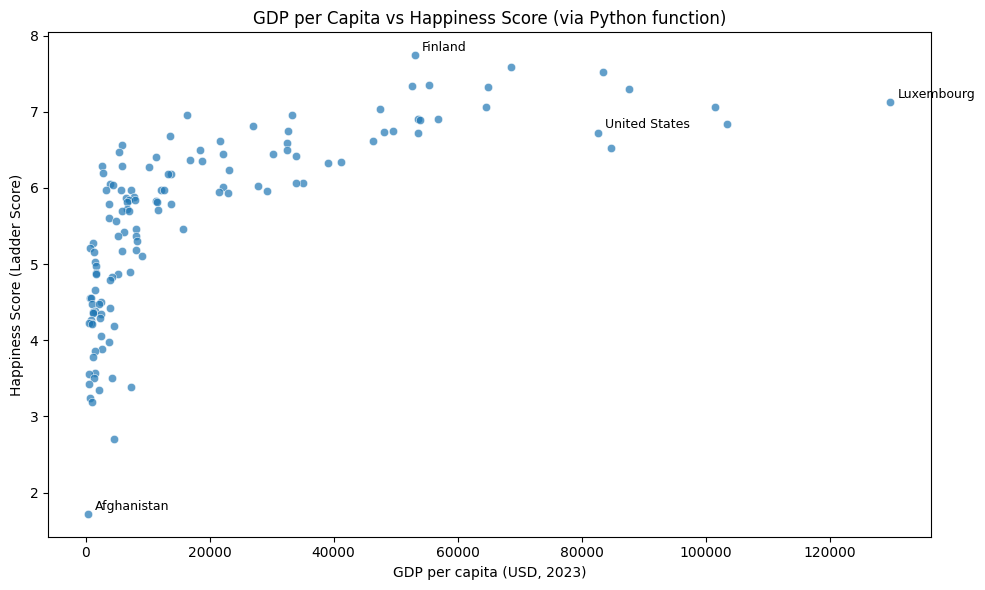

In [63]:
# Same scatter plot -- now powered by a single import
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_merged2["gdp_per_capita"],
    df_merged2["ladder_score"],
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
)

for _, row in df_merged2.iterrows():
    if row["country_name"] in ["Finland", "United States", "Luxembourg", "Afghanistan"]:
        ax.annotate(
            row["country_name"],
            xy=(row["gdp_per_capita"], row["ladder_score"]),
            xytext=(5, 3),
            textcoords="offset points",
            fontsize=9,
        )

ax.set_xlabel("GDP per capita (USD, 2023)")
ax.set_ylabel("Happiness Score (Ladder Score)")
ax.set_title("GDP per Capita vs Happiness Score (via Python function)")
plt.tight_layout()
plt.show()

**The result is identical** -- but now the entire merge pipeline is a single import.
Any other notebook can replicate this analysis with just two lines:

```python
from src.data.data_merge import merge_gdp_happiness
df = merge_gdp_happiness(year=2023)
```

---
## Full Summary

| Concept | What we did | Key tool |
|---------|-------------|----------|
| **Reshaping** | Converted long to wide format | `pivot()` |
| **Python files** | Moved reusable logic into `.py` files | `import` |
| **Index columns** | Set `(iso, year)` as a MultiIndex | `set_index()` / `.loc[]` |
| **Datetime** | Converted integer year to `datetime64` | `pd.to_datetime()` |
| **Merging** | Joined IMF GDP data with happiness data | `pd.merge()` |
| **Merge as a Python file** | `data_merge.py` encapsulates all merge logic | `merge_gdp_happiness()` |